In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
from pathlib import Path
import os
import torch
import torchaudio as ta

root_path = Path.cwd().parent
os.sys.path.insert(0, str(root_path))
import plot_functions as plot
from configs import get_specgram_config
import feature_utils as futils
import utils

In [9]:
graph_path = Path.cwd().parent / "graphs" / "week11_graphs" / "spectrogram_inspection"

s_path = r"D:\clustering\clustering_outputs_6064\downsampled_features\6229.220918014000.npz"
s_orig_path = r"D:\data_dryad\Sep_6229\6229.220918014000.wav"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
specgram_configs = get_specgram_config()
specgram_configs["n_fft"] = 2048//2
transf = utils.PipelineSpecgram(specgram_config=specgram_configs).to(device).eval()
original_frames = 33124

c:\Users\Lindholm\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchaudio\functional\functional.py:584: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (513) may be set too low.
  warnings.warn(


(8000, 88)


(<Figure size 800x500 with 2 Axes>,
 <Axes: title={'center': 'plot_feat_ds_sample.png'}, xlabel='Time (s)', ylabel='Frequency (kHz)'>)

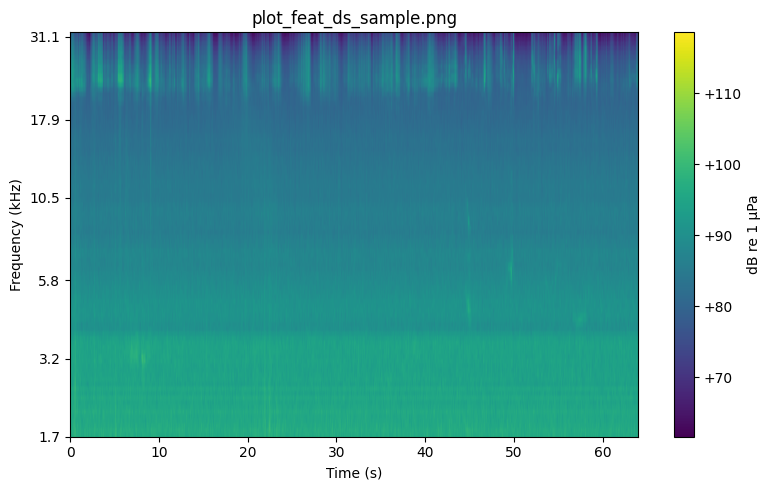

In [10]:
s1 = np.load(s_path)
print(s1["feature_ds"].shape)
s1 = torch.tensor(s1["feature_ds"]).to(device)

fname = "plot_feat_ds_sample.png"
out_png = graph_path
plot.plot_features(s1, transf=transf, specgram_config=specgram_configs, path=out_png
    , title=fname, mel_idx_start=40, n_mels_full=128, unit="freq")

torch.Size([33125, 128])


(<Figure size 800x500 with 2 Axes>,
 <Axes: title={'center': 'plot_feat_test1.png'}, xlabel='Time (s)', ylabel='Frequency (kHz)'>)

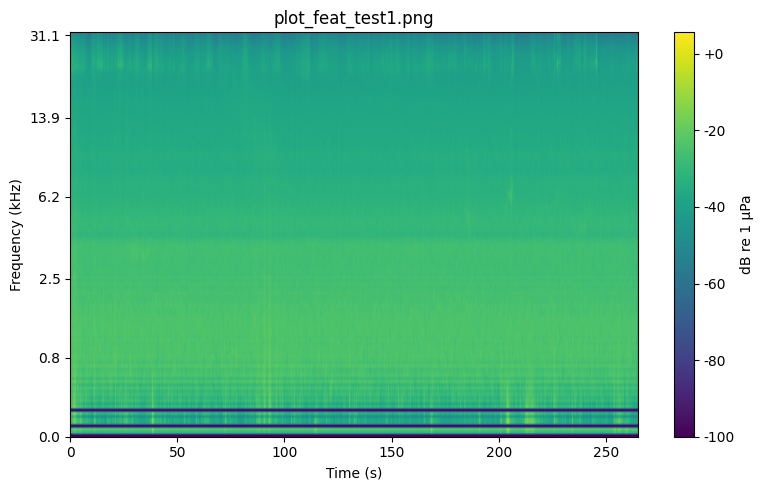

In [21]:
graph_tests_folder = r"C:\Users\Lindholm\Documents\BSc\bsc_project\research\graphs\graph_tests_wk12"
s_t1_pth = r"D:\second_extraction\Sep_6229\6229.220918014000.npz"
s1_t1 = np.load(s_t1_pth)
s1_t1 = torch.tensor(s1_t1["feature"]).to(device)
s1_t1 = s1_t1.squeeze(0).T
print(s1_t1.shape)
    
fname = "plot_feat_test1.png"
out_png = graph_tests_folder
plot.plot_features(s1_t1, transf=transf, specgram_config=specgram_configs, path=out_png
    , title=fname, mel_idx_start=0, n_mels_full=128, unit="freq")

In [4]:
wave1, sr1 = ta.load(s_orig_path)
wave1 = wave1
print("wave1 shape:", wave1.shape, "sr1:", sr1)
n_fft = specgram_configs["n_fft"]
hop_length = specgram_configs["hop_length"]
n_mels = specgram_configs["n_mels"]

wave1 shape: torch.Size([1, 17277904]) sr1: 64000


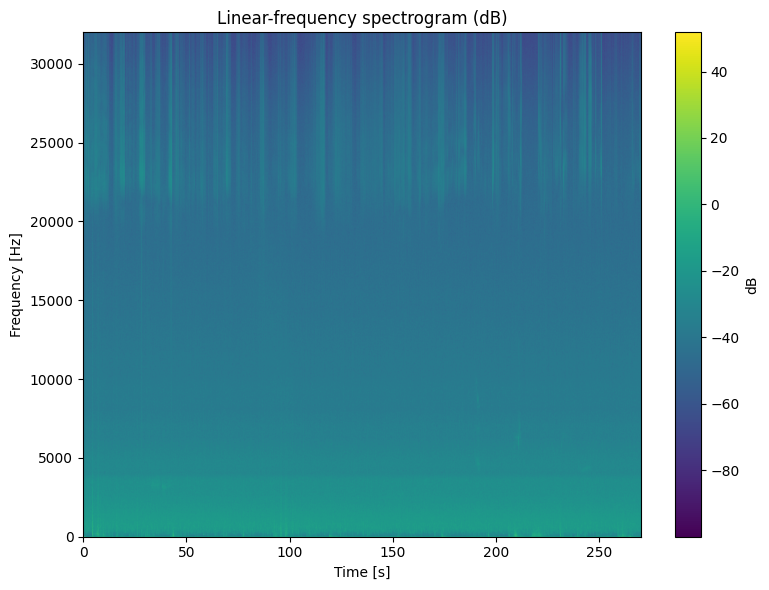

In [5]:
spec_transf = ta.transforms.Spectrogram(n_fft=n_fft*2
    , hop_length=hop_length
    , power=2.0)(wave1)

S = spec_transf[0]   # (n_freq, n_frames)

# Convert to dB: 10 * log10(power)
S_db = 10 * torch.log10(S + 1e-10)

plt.figure(figsize=(8, 6))
# extent for nicer axes: time vs frequency
time_axis = torch.arange(S.shape[1]) * hop_length / sr1
freq_axis = torch.linspace(0, sr1/2, S.shape[0])

plt.imshow(S_db.cpu().numpy(),
           aspect="auto",
           origin="lower",
           extent=[time_axis[0].item(), time_axis[-1].item(),
                   freq_axis[0].item(), freq_axis[-1].item()])
plt.colorbar(label="dB")
plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")
plt.title("Linear-frequency spectrogram (dB)")
plt.tight_layout()
plt.show()

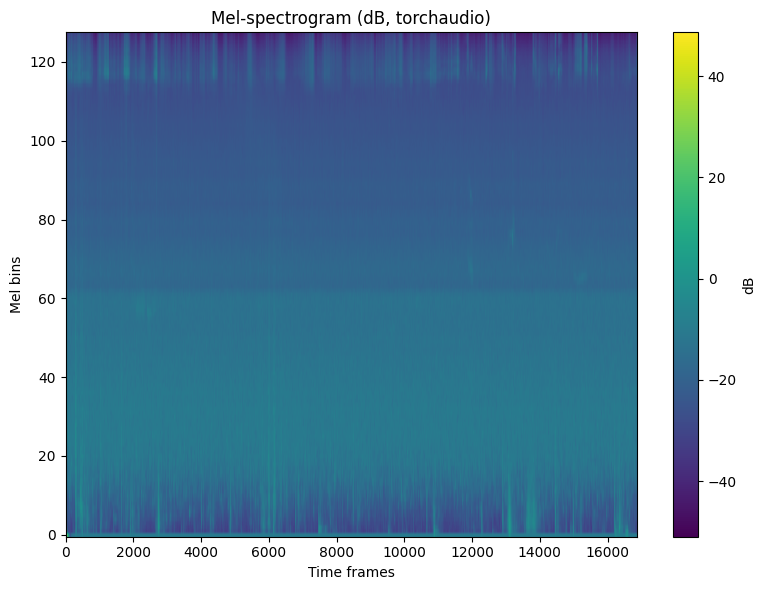

In [6]:
mel_transform = ta.transforms.MelSpectrogram(
    sample_rate=sr1,
    n_fft= n_fft*2,
    hop_length=hop_length*2,
    n_mels=n_mels,
    f_min=0.0,
    f_max=sr1/2,
    power=2.0, # power mel-spectrogram
)

M = mel_transform(wave1)[0] # (n_mels, n_frames)
M_db = 10 * torch.log10(M + 1e-10)

plt.figure(figsize=(8, 6))
plt.imshow(M_db.cpu().numpy(),
           aspect="auto",
           origin="lower")
plt.colorbar(label="dB")
plt.xlabel("Time frames")
plt.ylabel("Mel bins")
plt.title("Mel-spectrogram (dB, torchaudio)")
plt.tight_layout()
plt.show()

torch.Size([1, 128, 33121])
torch.Size([33121, 128])
torch.Size([33121, 88])
torch.Size([20000, 88])
torch.Size([1, 20000, 88])


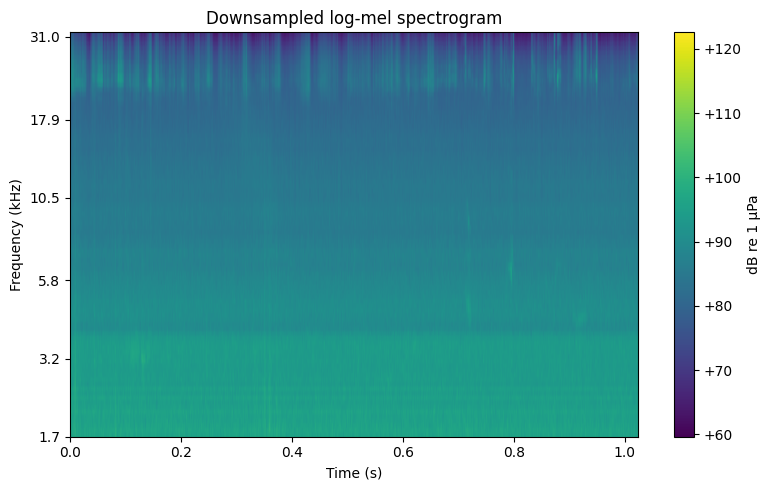

In [7]:
s2_path = r"D:\logmel_outputs_9979\Sep_6229\6229.220918014000.npz"
s2 = np.load(s2_path)
s2 = torch.tensor(s2["feature"])
N_MELS = specgram_configs["n_mels"]
print(s2.shape)
drop_mels = 40
s2 = s2.squeeze(0).transpose(0, 1)
original_frames = s2.shape[1]
print(s2.shape)
s2 = s2[:, drop_mels:] # n_mels from 40 to 128?
print(s2.shape)
T_target = 20_000
s2_ds = futils.downsample_time_avgpool_from_db(s2, T_target, ref=1.0)
print(s2_ds.shape)
transf = utils.PipelineSpecgram(specgram_config=specgram_configs).to(device).eval()
plot.plot_features(s2_ds.unsqueeze(0), transf=transf, specgram_config=specgram_configs, path=graph_path / "s_ds_mel_scale.png"
              , title="Downsampled log-mel spectrogram", unit="freq", t_frames_original=original_frames, mel_idx_start=drop_mels, n_mels_full=128)
print(s2_ds.unsqueeze(0).shape)

torch.Size([8000, 88])
torch.Size([8000, 88])
torch.Size([8000, 88])
torch.Size([8000, 88])
torch.Size([1, 8000, 88])


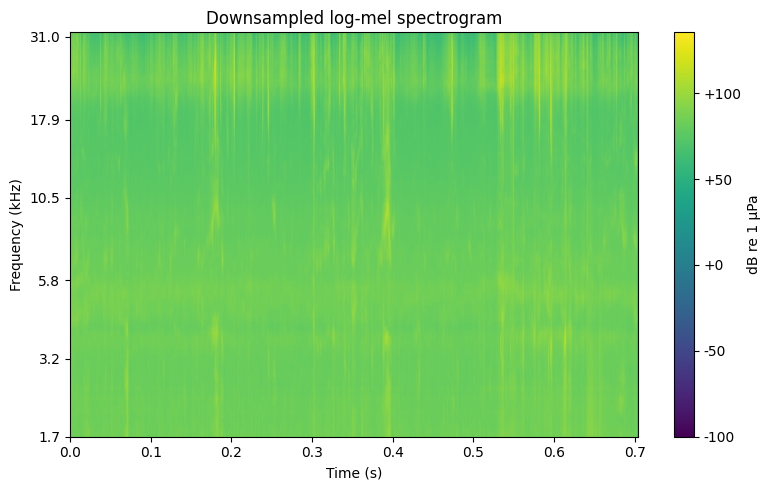

In [8]:
feat1_pth = r"D:\clustering\clustering_outputs_6064\downsampled_features\6230.220917120000.npz"
f1 = np.load(feat1_pth)
f1 = torch.tensor(f1["feature_ds"])
f1 = f1[:, :]
N_MELS = specgram_configs["n_mels"]
print(f1.shape)
drop_mels = 40
f1 = f1.squeeze(0)
original_frames = f1.shape[1]
print(f1.shape)
f1 = f1[:, :] # n_mels from 40 to 128?
print(f1.shape)
# T_target = 8000
# f1_ds = futils.downsample_time_avgpool_from_db(f1, T_target, ref=1.0)
f1_ds = f1
print(f1_ds.shape)
transf = utils.PipelineSpecgram(specgram_config=specgram_configs).to(device).eval()
plot.plot_features(f1_ds.unsqueeze(0), transf=transf, specgram_config=specgram_configs, path=graph_path / "s_ds_mel_scale.png"
              , title="Downsampled log-mel spectrogram", unit="freq", t_frames_original=original_frames, mel_idx_start=drop_mels, n_mels_full=128)
print(f1_ds.unsqueeze(0).shape)